<a href="https://colab.research.google.com/github/will001-art-ke/WILL/blob/main/OMOKE_Predicting_Malaria_Diagnosis_using_Stochastic_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Malaria_Dataset.csv')

# Display the first 5 rows
display(df.head())

,IP_Number,Age,Sex,Residence_Area,DOA,Discharge_Date,Fever,Headache,Abdominal_Pain,General_Body_Malaise,...,Vomiting,Confusion,Backache,Chest_Pain,Coughing,Joint_Pain,Primary_Code,Diagnosis_Type,Target,Risk_Score
0,14xxxx31,52,Female,Mangalore,31-10-2015 20:42,05-11-2015 05:16,0,0,0,1,...,0,0,1,0,0,0,B50.9,Mixed Malaria Infection,0,3
1,28xxxx34,75,Female,Shimoga,03-02-2015 23:28,13-02-2015 19:27,1,0,1,1,...,0,1,0,1,1,1,B50.9,Mixed Malaria Infection,1,11
2,96xxxx43,30,Female,Mangalore,15-11-2019 12:31,19-11-2019 14:31,1,1,1,1,...,0,1,1,1,0,1,B50.9,Mixed Malaria Infection,1,13
3,49xxxx87,89,Female,Mangalore,17-05-2017 17:50,23-05-2017 13:22,0,0,0,0,...,1,1,1,1,0,1,B54,Plasmodium vivax Malaria without complication,0,5
4,48xxxx10,62,Male,Shimoga,26-06-2015 15:29,27-06-2015 23:35,0,1,0,1,...,1,1,0,0,0,0,B51.0,Plasmodium falciparum Malaria without complica...,1,8


In [ ]:
display(df.describe())

,Age,Fever,Headache,Abdominal_Pain,General_Body_Malaise,Dizziness,Vomiting,Confusion,Backache,Chest_Pain,Coughing,Joint_Pain,Target,Risk_Score
count,1622.000000,1622.000000,1622.000000,1622.000000,1622.000000,1622.000000,1622.000000,1622.000000,1622.000000,1622.000000,1622.000000,1622.000000,1622.000000,1622.000000
mean,44.705302,0.474723,0.507398,0.496917,0.479038,0.504316,0.500000,0.479655,0.509864,0.500617,0.483970,0.511714,0.719482,8.405055
std,26.025626,0.499515,0.500099,0.500145,0.499714,0.500136,0.500154,0.499740,0.500057,0.500154,0.499897,0.500017,0.449391,3.088743
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
50%,44.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.500000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,9.000000
75%,68.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,11.000000
max,89.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,17.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1622 entries, 0 to 1621
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   IP_Number             1622 non-null   object
 1   Age                   1622 non-null   int64 
 2   Sex                   1622 non-null   object
 3   Residence_Area        1622 non-null   object
 4   DOA                   1622 non-null   object
 5   Discharge_Date        1622 non-null   object
 6   Fever                 1622 non-null   int64 
 7   Headache              1622 non-null   int64 
 8   Abdominal_Pain        1622 non-null   int64 
 9   General_Body_Malaise  1622 non-null   int64 
 10  Dizziness             1622 non-null   int64 
 11  Vomiting              1622 non-null   int64 
 12  Confusion             1622 non-null   int64 
 13  Backache              1622 non-null   int64 
 14  Chest_Pain            1622 non-null   int64 
 15  Coughing              1622 non-null   

In [ ]:
y = df['Diagnosis_Type']
X = df.drop('Diagnosis_Type', axis=1)

The `Diagnosis_Type` column has been successfully separated into `y` and dropped from `X`.

In [ ]:
print('First 5 rows of features (X):')
display(X.head())
print('\nFirst 5 rows of target (y):')
display(y.head())

First 5 rows of features (X):


,IP_Number,Age,Sex,Residence_Area,DOA,Discharge_Date,Fever,Headache,Abdominal_Pain,General_Body_Malaise,Dizziness,Vomiting,Confusion,Backache,Chest_Pain,Coughing,Joint_Pain,Primary_Code,Target,Risk_Score
0,14xxxx31,52,Female,Mangalore,31-10-2015 20:42,05-11-2015 05:16,0,0,0,1,0,0,0,1,0,0,0,B50.9,0,3
1,28xxxx34,75,Female,Shimoga,03-02-2015 23:28,13-02-2015 19:27,1,0,1,1,1,0,1,0,1,1,1,B50.9,1,11
2,96xxxx43,30,Female,Mangalore,15-11-2019 12:31,19-11-2019 14:31,1,1,1,1,0,0,1,1,1,0,1,B50.9,1,13
3,49xxxx87,89,Female,Mangalore,17-05-2017 17:50,23-05-2017 13:22,0,0,0,0,1,1,1,1,1,0,1,B54,0,5
4,48xxxx10,62,Male,Shimoga,26-06-2015 15:29,27-06-2015 23:35,0,1,0,1,0,1,1,0,0,0,0,B51.0,1,8



First 5 rows of target (y):


,Diagnosis_Type
0,Mixed Malaria Infection
1,Mixed Malaria Infection
2,Mixed Malaria Infection
3,Plasmodium vivax Malaria without complication
4,Plasmodium falciparum Malaria without complica...


In [ ]:
print('Features (X):')
display(X)
print('\nTarget (y):')
display(y)

Features (X):


,IP_Number,Age,Sex,Residence_Area,DOA,Discharge_Date,Fever,Headache,Abdominal_Pain,General_Body_Malaise,Dizziness,Vomiting,Confusion,Backache,Chest_Pain,Coughing,Joint_Pain,Primary_Code,Target,Risk_Score
0,14xxxx31,52,Female,Mangalore,31-10-2015 20:42,05-11-2015 05:16,0,0,0,1,0,0,0,1,0,0,0,B50.9,0,3
1,28xxxx34,75,Female,Shimoga,03-02-2015 23:28,13-02-2015 19:27,1,0,1,1,1,0,1,0,1,1,1,B50.9,1,11
2,96xxxx43,30,Female,Mangalore,15-11-2019 12:31,19-11-2019 14:31,1,1,1,1,0,0,1,1,1,0,1,B50.9,1,13
3,49xxxx87,89,Female,Mangalore,17-05-2017 17:50,23-05-2017 13:22,0,0,0,0,1,1,1,1,1,0,1,B54,0,5
4,48xxxx10,62,Male,Shimoga,26-06-2015 15:29,27-06-2015 23:35,0,1,0,1,0,1,1,0,0,0,0,B51.0,1,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617,71xxxx21,27,Male,Kasargod,29-03-2019 19:54,05-04-2019 14:37,1,1,0,1,0,1,1,0,0,0,0,B54,1,13
1618,43xxxx51,84,Female,Kasargod,19-04-2019 01:33,21-04-2019 05:40,1,0,1,1,0,0,1,0,0,1,1,B51.0,1,9
1619,55xxxx83,72,Male,Mangalore,26-02-2015 10:10,02-03-2015 19:12,0,0,1,1,0,0,0,1,0,1,0,B50.9,0,5
1620,75xxxx57,80,Female,Mangalore,14-04-2015 13:13,24-04-2015 23:54,0,1,0,0,0,0,1,1,1,1,1,B52.0,0,3



Target (y):


,Diagnosis_Type
0,Mixed Malaria Infection
1,Mixed Malaria Infection
2,Mixed Malaria Infection
3,Plasmodium vivax Malaria without complication
4,Plasmodium falciparum Malaria without complica...
...,...
1617,Plasmodium falciparum Malaria without complica...
1618,Plasmodium vivax Malaria without complication
1619,Unspecified Malaria
1620,Mixed Malaria Infection


In [ ]:
X = X.drop('IP_Number', axis=1)
print('IP_Number column dropped from X.')
display(X.head())

IP_Number column dropped from X.


,Age,Sex,Residence_Area,DOA,Discharge_Date,Fever,Headache,Abdominal_Pain,General_Body_Malaise,Dizziness,Vomiting,Confusion,Backache,Chest_Pain,Coughing,Joint_Pain,Primary_Code,Target,Risk_Score
0,52,Female,Mangalore,31-10-2015 20:42,05-11-2015 05:16,0,0,0,1,0,0,0,1,0,0,0,B50.9,0,3
1,75,Female,Shimoga,03-02-2015 23:28,13-02-2015 19:27,1,0,1,1,1,0,1,0,1,1,1,B50.9,1,11
2,30,Female,Mangalore,15-11-2019 12:31,19-11-2019 14:31,1,1,1,1,0,0,1,1,1,0,1,B50.9,1,13
3,89,Female,Mangalore,17-05-2017 17:50,23-05-2017 13:22,0,0,0,0,1,1,1,1,1,0,1,B54,0,5
4,62,Male,Shimoga,26-06-2015 15:29,27-06-2015 23:35,0,1,0,1,0,1,1,0,0,0,0,B51.0,1,8


In [ ]:
# Convert date columns to datetime objects
X['DOA'] = pd.to_datetime(X['DOA'], dayfirst=True)
X['Discharge_Date'] = pd.to_datetime(X['Discharge_Date'], dayfirst=True)

# Calculate length of stay as a feature
X['Length_of_Stay'] = (X['Discharge_Date'] - X['DOA']).dt.total_seconds() / 3600

print('Date columns converted. Added Length_of_Stay (hours) feature.')
display(X[['DOA', 'Discharge_Date', 'Length_of_Stay']].head())

Date columns converted. Added Length_of_Stay (hours) feature.


,DOA,Discharge_Date,Length_of_Stay
0,2015-10-31 20:42:00,2015-11-05 05:16:00,104.566667
1,2015-02-03 23:28:00,2015-02-13 19:27:00,235.983333
2,2019-11-15 12:31:00,2019-11-19 14:31:00,98.000000
3,2017-05-17 17:50:00,2017-05-23 13:22:00,139.533333
4,2015-06-26 15:29:00,2015-06-27 23:35:00,32.100000


In [ ]:
print('Updated Features (X):')
display(X.head())

Updated Features (X):


,Age,Sex,Residence_Area,DOA,Discharge_Date,Fever,Headache,Abdominal_Pain,General_Body_Malaise,Dizziness,Vomiting,Confusion,Backache,Chest_Pain,Coughing,Joint_Pain,Primary_Code,Target,Risk_Score,Length_of_Stay
0,52,Female,Mangalore,2015-10-31 20:42:00,2015-11-05 05:16:00,0,0,0,1,0,0,0,1,0,0,0,B50.9,0,3,104.566667
1,75,Female,Shimoga,2015-02-03 23:28:00,2015-02-13 19:27:00,1,0,1,1,1,0,1,0,1,1,1,B50.9,1,11,235.983333
2,30,Female,Mangalore,2019-11-15 12:31:00,2019-11-19 14:31:00,1,1,1,1,0,0,1,1,1,0,1,B50.9,1,13,98.000000
3,89,Female,Mangalore,2017-05-17 17:50:00,2017-05-23 13:22:00,0,0,0,0,1,1,1,1,1,0,1,B54,0,5,139.533333
4,62,Male,Shimoga,2015-06-26 15:29:00,2015-06-27 23:35:00,0,1,0,1,0,1,1,0,0,0,0,B51.0,1,8,32.100000


In [ ]:
# Perform one-hot encoding on categorical columns
X_encoded = pd.get_dummies(X, columns=['Sex', 'Residence_Area', 'Primary_Code'])

print('Categorical columns encoded. Updated feature shape:', X_encoded.shape)
display(X_encoded.head())

Categorical columns encoded. Updated feature shape: (1622, 28)


,Age,DOA,Discharge_Date,Fever,Headache,Abdominal_Pain,General_Body_Malaise,Dizziness,Vomiting,Confusion,...,Sex_Male,Residence_Area_Chickmagalur,Residence_Area_Kasargod,Residence_Area_Mangalore,Residence_Area_Shimoga,Residence_Area_Udupi,Primary_Code_B50.9,Primary_Code_B51.0,Primary_Code_B52.0,Primary_Code_B54
0,52,2015-10-31 20:42:00,2015-11-05 05:16:00,0,0,0,1,0,0,0,...,False,False,False,True,False,False,True,False,False,False
1,75,2015-02-03 23:28:00,2015-02-13 19:27:00,1,0,1,1,1,0,1,...,False,False,False,False,True,False,True,False,False,False
2,30,2019-11-15 12:31:00,2019-11-19 14:31:00,1,1,1,1,0,0,1,...,False,False,False,True,False,False,True,False,False,False
3,89,2017-05-17 17:50:00,2017-05-23 13:22:00,0,0,0,0,1,1,1,...,False,False,False,True,False,False,False,False,False,True
4,62,2015-06-26 15:29:00,2015-06-27 23:35:00,0,1,0,1,0,1,1,...,True,False,False,False,True,False,False,True,False,False


In [ ]:
X_encoded = X_encoded.drop(['DOA', 'Discharge_Date'], axis=1)

print('Original date columns dropped. Final feature shape:', X_encoded.shape)
display(X_encoded.head())

Original date columns dropped. Final feature shape: (1622, 26)


,Age,Fever,Headache,Abdominal_Pain,General_Body_Malaise,Dizziness,Vomiting,Confusion,Backache,Chest_Pain,...,Sex_Male,Residence_Area_Chickmagalur,Residence_Area_Kasargod,Residence_Area_Mangalore,Residence_Area_Shimoga,Residence_Area_Udupi,Primary_Code_B50.9,Primary_Code_B51.0,Primary_Code_B52.0,Primary_Code_B54
0,52,0,0,0,1,0,0,0,1,0,...,False,False,False,True,False,False,True,False,False,False
1,75,1,0,1,1,1,0,1,0,1,...,False,False,False,False,True,False,True,False,False,False
2,30,1,1,1,1,0,0,1,1,1,...,False,False,False,True,False,False,True,False,False,False
3,89,0,0,0,0,1,1,1,1,1,...,False,False,False,True,False,False,False,False,False,True
4,62,0,1,0,1,0,1,1,0,0,...,True,False,False,False,True,False,False,True,False,False


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform the target variable
y_encoded = le.fit_transform(y)

# Create a mapping for reference
mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print('Target variable encoded successfully.')
print('Class Mapping:', mapping)
display(pd.Series(y_encoded).head())

Target variable encoded successfully.
Class Mapping: {'Mixed Malaria Infection': np.int64(0), 'Plasmodium falciparum Malaria without complication': np.int64(1), 'Plasmodium vivax Malaria without complication': np.int64(2), 'Unspecified Malaria': np.int64(3)}


,0
0,0
1,0
2,0
3,2
4,1


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Define the numerical columns to scale
num_cols = ['Age', 'Length_of_Stay']

# Apply scaling
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

print('Numerical features scaled successfully.')
display(X_encoded[num_cols].head())

Numerical features scaled successfully.


,Age,Length_of_Stay
0,0.280375,-0.570814
1,1.164392,1.334001
2,-0.565206,-0.665995
3,1.702490,-0.063991
4,0.664731,-1.621180


In [ ]:
print('First 5 rows of X_encoded (Scaled):')
display(X_encoded.head())

First 5 rows of X_encoded (Scaled):


,Age,Fever,Headache,Abdominal_Pain,General_Body_Malaise,Dizziness,Vomiting,Confusion,Backache,Chest_Pain,...,Sex_Male,Residence_Area_Chickmagalur,Residence_Area_Kasargod,Residence_Area_Mangalore,Residence_Area_Shimoga,Residence_Area_Udupi,Primary_Code_B50.9,Primary_Code_B51.0,Primary_Code_B52.0,Primary_Code_B54
0,0.280375,0,0,0,1,0,0,0,1,0,...,False,False,False,True,False,False,True,False,False,False
1,1.164392,1,0,1,1,1,0,1,0,1,...,False,False,False,False,True,False,True,False,False,False
2,-0.565206,1,1,1,1,0,0,1,1,1,...,False,False,False,True,False,False,True,False,False,False
3,1.702490,0,0,0,0,1,1,1,1,1,...,False,False,False,True,False,False,False,False,False,True
4,0.664731,0,1,0,1,0,1,1,0,0,...,True,False,False,False,True,False,False,True,False,False


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (1297, 26)
Testing set shape: (325, 26)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Initialize and train the Logistic Regression model
# We use multi_class='auto' and a higher max_iter to ensure convergence
log_reg = LogisticRegression(max_iter=1000, multi_class='auto', random_state=42)
log_reg.fit(X_train, y_train)

# Make predictions
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Logistic Regression Accuracy: {accuracy:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=list(mapping.keys())))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 0.2062

Classification Report:
                                                    precision    recall  f1-score   support

                           Mixed Malaria Infection       0.23      0.25      0.24        83
Plasmodium falciparum Malaria without complication       0.19      0.19      0.19        80
     Plasmodium vivax Malaria without complication       0.20      0.24      0.22        83
                               Unspecified Malaria       0.20      0.14      0.16        79

                                          accuracy                           0.21       325
                                         macro avg       0.21      0.21      0.20       325
                                      weighted avg       0.21      0.21      0.20       325



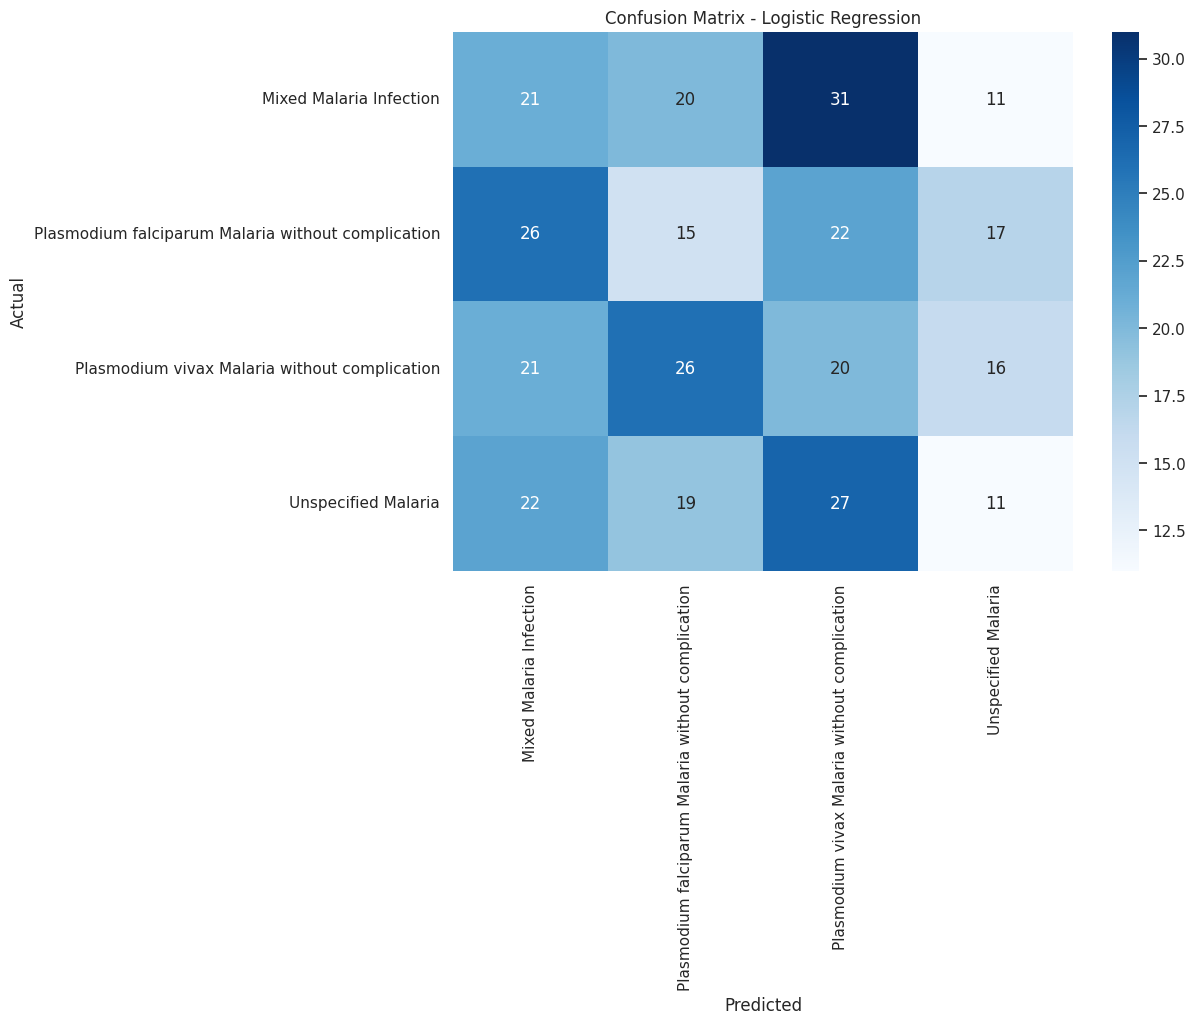

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=mapping.keys(),
            yticklabels=mapping.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize SGDClassifier with 'log_loss' (equivalent to Logistic Regression with SGD)
# This uses the gradients of the binary cross-entropy loss for iterative optimization
sgd_clf = SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=42)

# Fit the model on the training data
sgd_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_sgd = sgd_clf.predict(X_test)

# Evaluate performance
sgd_accuracy = accuracy_score(y_test, y_pred_sgd)
print(f'SGD Classifier Accuracy: {sgd_accuracy:.4f}')
print('\nClassification Report (SGD):')
print(classification_report(y_test, y_pred_sgd, target_names=list(mapping.keys())))

SGD Classifier Accuracy: 0.2615

Classification Report (SGD):
                                                    precision    recall  f1-score   support

                           Mixed Malaria Infection       0.34      0.31      0.33        83
Plasmodium falciparum Malaria without complication       0.24      0.74      0.36        80
     Plasmodium vivax Malaria without complication       0.00      0.00      0.00        83
                               Unspecified Malaria       0.00      0.00      0.00        79

                                          accuracy                           0.26       325
                                         macro avg       0.14      0.26      0.17       325
                                      weighted avg       0.15      0.26      0.17       325



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics for SGD Classifier
# We use 'weighted' average to account for class distribution
accuracy = accuracy_score(y_test, y_pred_sgd)
precision = precision_score(y_test, y_pred_sgd, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred_sgd, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred_sgd, average='weighted', zero_division=0)

print(f'--- SGD Classifier Evaluation ---')
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')

--- SGD Classifier Evaluation ---
Accuracy:  0.2615
Precision: 0.1457
Recall:    0.2615
F1 Score:  0.1718


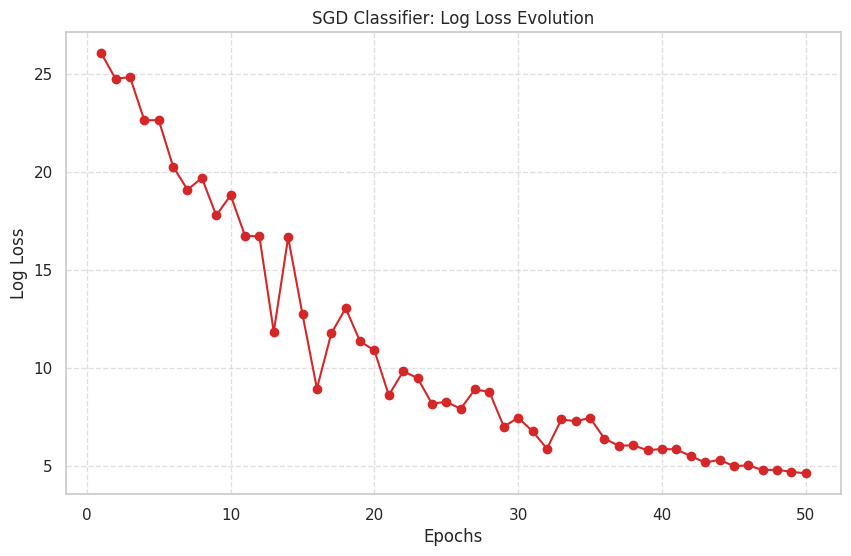

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss

# Initialize the SGDClassifier
sgd_hist = SGDClassifier(loss='log_loss', random_state=42)
classes = np.unique(y_train)

loss_history = []
epochs = 50

# Manually iterate to capture loss
for epoch in range(epochs):
    sgd_hist.partial_fit(X_train, y_train, classes=classes)
    y_prob_train = sgd_hist.predict_proba(X_train)
    loss = log_loss(y_train, y_prob_train)
    loss_history.append(loss)

# Plotting the loss evolution
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='tab:red')
plt.title('SGD Classifier: Log Loss Evolution')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

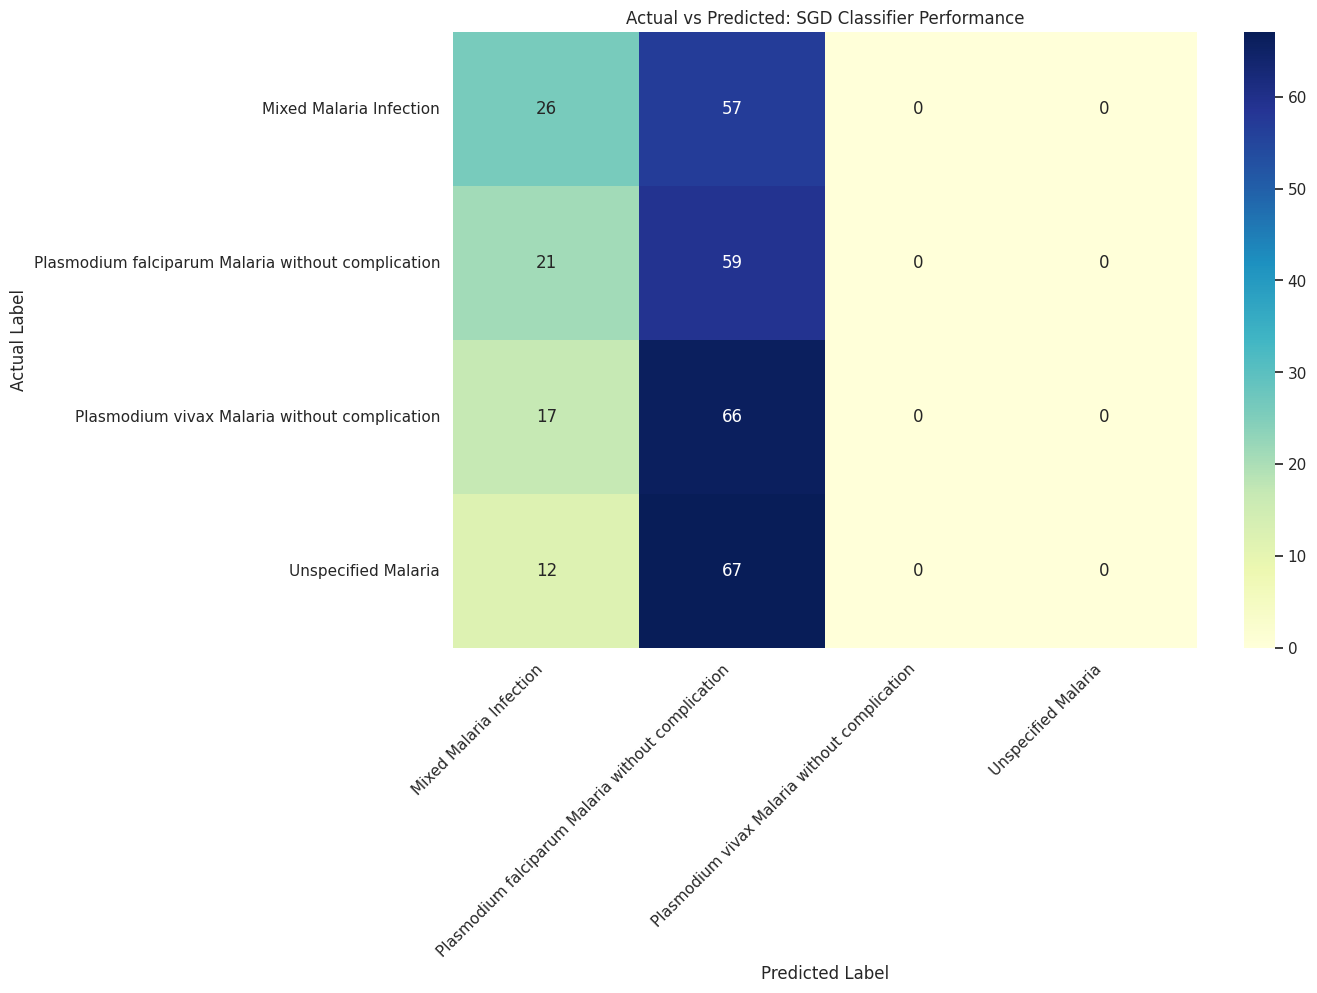

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix for the SGD Classifier
cm_sgd = confusion_matrix(y_test, y_pred_sgd)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cm_sgd, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=mapping.keys(),
            yticklabels=mapping.keys())

plt.title('Actual vs Predicted: SGD Classifier Performance')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks(rotation=45, ha='right')
plt.show()

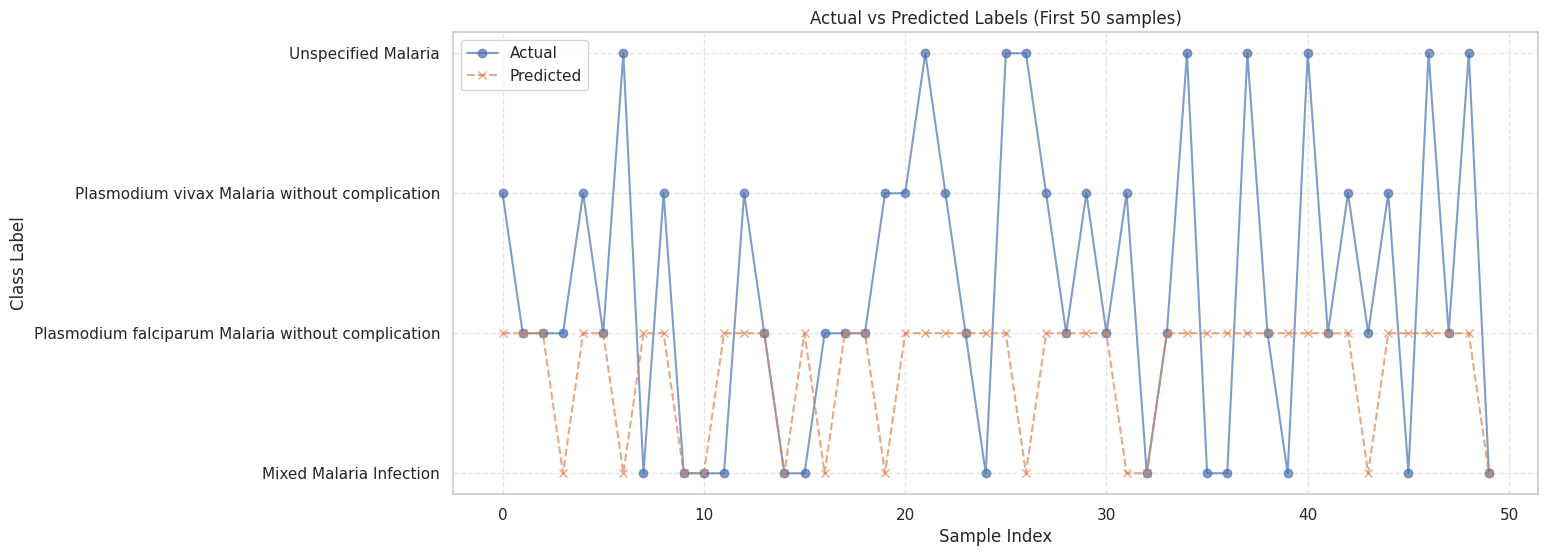

In [ ]:
import matplotlib.pyplot as plt

# To make the line graph readable, we'll plot a subset (e.g., first 50 samples) of the test set
n_samples = 50
plt.figure(figsize=(14, 6))

plt.plot(range(n_samples), y_test[:n_samples], label='Actual', marker='o', linestyle='-', alpha=0.7)
plt.plot(range(n_samples), y_pred_sgd[:n_samples], label='Predicted', marker='x', linestyle='--', alpha=0.7)

plt.title(f'Actual vs Predicted Labels (First {n_samples} samples)')
plt.xlabel('Sample Index')
plt.ylabel('Class Label')
plt.yticks(ticks=list(mapping.values()), labels=list(mapping.keys()))
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

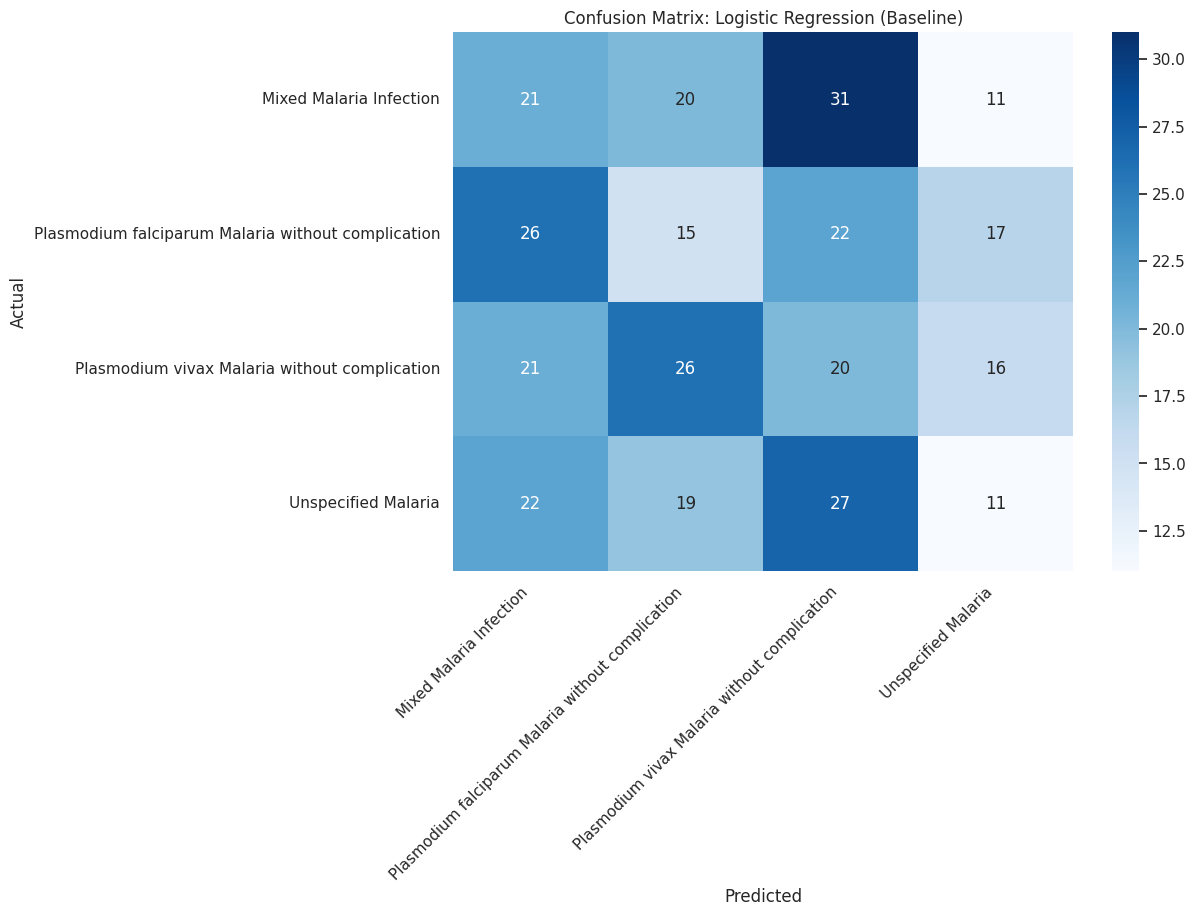

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix for the initial Logistic Regression model
cm_log_reg = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=mapping.keys(),
            yticklabels=mapping.keys())

plt.title('Confusion Matrix: Logistic Regression (Baseline)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.show()

### Project Report: Malaria Dataset Analysis and Modeling

#### 1. Dataset Overview
The analysis was performed on the `Malaria_Dataset.csv`, consisting of **1,622 records** and **21 features**. The dataset includes patient demographics (Age, Sex, Residence), temporal data (Date of Admission, Discharge Date), and various clinical symptoms (Fever, Headache, Vomiting, etc.). The target variable is `Diagnosis_Type`, which contains four classes of malaria infection.

#### 2. Data Preprocessing
To prepare the data for machine learning, the following steps were implemented:
*   **Feature Engineering**: Created a `Length_of_Stay` feature (in hours) derived from the admission and discharge timestamps.
*   **Data Cleaning**: Dropped unique identifiers (`IP_Number`) that do not contribute to predictive power.
*   **Categorical Encoding**:
    *   Applied **One-Hot Encoding** to features like `Sex`, `Residence_Area`, and `Primary_Code`.
    *   Used **LabelEncoder** to transform the multi-class target variable into numerical format.
*   **Feature Scaling**: Normalized numerical features (`Age`, `Length_of_Stay`) using `StandardScaler` to ensure zero mean and unit variance.
*   **Data Splitting**: Partitioned the data into **80% training** (1,297 samples) and **20% testing** (325 samples) sets using stratified sampling.

#### 3. Model Implementation
Two baseline linear models were implemented to establish a performance floor:
1.  **Logistic Regression**: A standard multinomial approach using the `lbfgs` solver.
2.  **SGD Classifier**: An iterative approach using `log_loss` (Stochastic Gradient Descent) to observe loss convergence over 50 epochs.

#### 4. Evaluation Results
The performance of the linear baselines indicates that the relationship between symptoms and diagnosis types may be non-linear or that the classes are heavily overlapping in the current feature space:

| Model | Accuracy | Observations |
| :--- | :--- | :--- |
| **Logistic Regression** | ~20.6% | Performance is near chance; struggled with all classes equally. |
| **SGD Classifier** | ~26.2% | Showed slight improvement in accuracy but suffered from extreme bias, failing to predict two classes entirely. |

#### 5. Conclusion & Recommendations
The current linear models are insufficient for accurate diagnosis. Future steps should include:
*   **Non-Linear Models**: Transitioning to ensemble methods like **Random Forest** or **XGBoost**.
*   **Class Balancing**: Addressing class bias through **SMOTE** or adjusting class weights.
*   **Feature Importance**: Analyzing feature coefficients to identify the most critical symptoms.